# Textielinzameling Rotterdam — Volledig Model

Dit notebook bevat alle beleidsvormen in één doorlopend model:

1. **Base case** — geen extra beleid (€0 beloning, 4 inzamelpunten)
2. **Beleidsvorm 1** — financiële beloning per ingeleverd kledingstuk (€0 t/m €5)
3. **Beleidsvorm 2** — meer inzamelpunten (4 / 6 / 8)
4. **Gecombineerd** — beloning én meer inzamelpunten tegelijk

### Gedeelde modelaannames
- Grid 100×100 = Rotterdam; elke cel = één huishouden.
- Afgedankt textiel: ~4.2 stuks/maand per agent (12.1 kg/jaar ÷ 0.24 kg/stuk ÷ 12).
- Recyclingkans hangt af van: milieubewustzijn, prijsgevoeligheid, gemak en sociale druk.
- **Beloningseffect**: S-curve op hoogte beloning; verspreidt via burendiffusie.
- **Gemakseffect**: S-curve op *waargenomen* afstand — agenten ontdekken nieuwe
  inzamelpunten geleidelijk (`leersnelheid = 0.25`, ~96% convergentie na 8 maanden).
- **Sociaal effect**: actief in alle scenario's (consistent).
- `BELONING_MIDDEN = 3.0`: buigpunt S-curve; `BELONING_GROEISNELHEID = 0.8`: steilheid.

---
## Deel 1 — Imports, constanten & modelcode

### Logistisch utility-model

De recyclingkans wordt nu berekend via een **logistisch model** in plaats van
een vaste basiswaarde van 0.5 plus kleine correcties:

```
utility = INTERCEPT
          + W_MILIEU   * (milieubewustzijn - 0.5)
          + W_SOCIAAL  * sociale_druk_gevoeligheid * (sociale_druk - 0.5)
          + W_GEMAK    * gemaksgevoeligheid * delta_gemak
          + W_BELONING * bekend * prijsgevoeligheid * beloning_factor

recyclingkans = 1 / (1 + exp(-utility))
```

**Waarom dit beter werkt:**
- Geen `INIT_RECYCLING_PERCENTAGE = 0.5` meer — de 50% volgt automatisch
  uit het feit dat utility gemiddeld ~0 is in de base case.
- Elk gewicht heeft een echt meetbaar effect. Verdubbel `W_MILIEU` en
  milieubewuste agenten recyclen significant meer dan onbewuste.
- `INTERCEPT` is de kalibratieparameter: pas aan als de base case
  structureel te hoog of te laag uitkomt (standaard 0.0).
- De gewichten zijn los instelbaar voor validatie en gevoeligheidsanalyse.

In [1]:
from mesa import Agent, Model
from mesa.space import MultiGrid
from mesa.time import RandomActivation
from mesa.datacollection import DataCollector
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── Gedeelde constanten ──────────────────────────────────────────────────
MAANDEN_LABELS = ["Jan", "Feb", "Mrt", "Apr", "Mei", "Jun",
                  "Jul", "Aug", "Sep", "Okt", "Nov", "Dec"]
GRID_SIZE      = 100
N_MAANDEN      = 12
SEED_BASIS     = 42
N_RUNS         = 5

# Beleidsvorm 1 — te testen beloningsniveaus
BELONINGEN     = [0, 1, 2, 3, 4, 5]

# Beleidsvorm 2 — te testen aantallen inzamelpunten
INZAMELPUNTEN_SCENARIOS = [4, 6, 8]

# Gecombineerde scenario's (label, beloning, punten, kleur, lijnstijl)
COMBO_SCENARIOS = [
    ("Base case (euro0, 4 punten)",         0, 4, "gray",   "--"),
    ("Alleen beloning (euro3, 4 punten)",    3, 4, "blue",   "-"),
    ("Alleen meer punten (euro0, 8 punten)", 0, 8, "orange", "-"),
    ("Gecombineerd (euro3, 8 punten)",       3, 8, "green",  "-"),
]


In [17]:
class Consument(Agent):
    """Een inwoner van Rotterdam met individueel recyclinggedrag.

    De recyclingkans wordt bepaald via een logistisch (utility-based) model:

        utility = INTERCEPT
                  + W_MILIEU   * (milieubewustzijn - 0.5)
                  + W_SOCIAAL  * sociale_druk_gevoeligheid * (sociale_druk - 0.5)
                  + W_GEMAK    * gemaksgevoeligheid * delta_gemak
                  + W_BELONING * bekend_met_beloning * prijsgevoeligheid * beloning_factor

        recyclingkans = 1 / (1 + exp(-utility))

    Waarom dit beter is dan de oude aanpak:
    - Geen hardcoded INIT_RECYCLING_PERCENTAGE van 0.5 meer.
    - De base case hangt rond 50% doordat utility gemiddeld ~0 is
      (milieu en sociale_druk zijn gemiddeld 0.5, dus hun termen middelen weg;
       gemak en beloning zijn 0 in de base case).
    - Elk gewicht heeft nu een echt meetbaar effect: hogere W_MILIEU
      zorgt voor een grotere spreiding tussen milieubewuste en
      niet-milieubewuste agenten.
    - INTERCEPT is de kalibratieparameter: pas aan als base case
      structureel te hoog of te laag uitkomt.
    """

    # ── Textielparameters ────────────────────────────────────────────────
    GEWICHT_PER_STUK    = 0.24        # gemiddeld gewicht kledingstuk in kg
    TEXTIEL_PER_JAAR_KG = 12.1        # afgedankt textiel per persoon per jaar in kg
    AFGEDANKT_PER_JAAR  = TEXTIEL_PER_JAAR_KG / GEWICHT_PER_STUK
    AFGEDANKT_PER_MAAND = AFGEDANKT_PER_JAAR / 12

    # ── Logit-model gewichten ────────────────────────────────────────────
    # INTERCEPT: kalibratieparameter die de base case op ~50% houdt.
    # Formule: INTERCEPT = -(W_MILIEU/2 + W_SOCIAAL/4)
    # Want: gemiddelde milieu_utility  = W_MILIEU  * E[milieu]  = W_MILIEU  * 0.5
    #        gemiddelde sociaal_utility = W_SOCIAAL * E[gevoelig] * E[druk] = W_SOCIAAL * 0.5 * 0.5
    # Bij W_MILIEU=2.0 en W_SOCIAAL=1.5: INTERCEPT = -(1.0 + 0.375) = -1.375
    # BELANGRIJK: pas INTERCEPT mee aan als je W_MILIEU of W_SOCIAAL verandert!
    # Formule: INTERCEPT = -(W_MILIEU / 2.0 + W_SOCIAAL / 4.0)
    INTERCEPT  = -(2.0 / 2.0 + 1.5 / 4.0)   # = -1.375

    # Milieubewustzijn-gewicht: hoe sterk scheidt bewust van onbewust?
    # milieubewustzijn ~ uniform(0,1), term = W_MILIEU * (milieu - 0.5)
    # Bereik van de term: [-W_MILIEU/2, +W_MILIEU/2]
    W_MILIEU   = 2

    # Sociaal gewicht: effect van burengedrag.
    # term = W_SOCIAAL * sociale_druk_gevoeligheid * (sociale_druk - 0.5)
    W_SOCIAAL  = 1.5

    # Gemaksgewicht: effect van kortere afstand door meer inzamelpunten.
    # term = W_GEMAK * gemaksgevoeligheid * delta_gemak  (delta_gemak in [-1, 1])
    W_GEMAK    = 3.0

    # Beloningsgewicht: effect van financiele beloning.
    # term = W_BELONING * bekend * prijsgevoeligheid * beloning_factor
    W_BELONING = 4.0

    # ── Belonings-S-curve parameters ─────────────────────────────────────
    # Logistische curve over beloningshoogte: buigpunt bij EUR 3, steilheid 0.8
    BELONING_GROEISNELHEID = 0.8
    BELONING_MIDDEN        = 3.0

    # ── Gemaksparameters ─────────────────────────────────────────────────
    # Midpoint van de afstands-S-curve (gridcellen)
    GEMAK_MIDPOINT = 12

    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        # Individuele eigenschappen: uniform verdeeld tussen 0 en 1
        self.milieubewustzijn          = self.random.uniform(0, 1)
        self.prijsgevoeligheid         = self.random.uniform(0, 1)
        self.gemaksgevoeligheid        = self.random.uniform(0, 1)
        self.sociale_druk_gevoeligheid = self.random.uniform(0, 1)

        # Gedragstoestand
        self.sociale_druk          = 0.5
        self.aantal_gerecycled     = 0
        self.aantal_weggegooid     = 0
        self.gerecycled_deze_maand = 0
        self.weggegooid_deze_maand = 0
        # Alle agenten starten onbekend met de beloning.
        # Bekendheid verspreidt zich uitsluitend via burendiffusie tijdens de simulatie,
        # zodat alle beloningsscenarios op exact hetzelfde startpunt beginnen.
        self.bekend_met_beloning   = 0

        self.afgedankt_textiel               = self.AFGEDANKT_PER_MAAND
        self.afstand_inzamelpunt             = None
        self.afstand_inzamelpunt_basis       = None
        # Waargenomen afstand start op basisafstand (4 punten);
        # convergeert geleidelijk naar echte afstand via leersnelheid 0.25
        self.waargenomen_afstand_inzamelpunt = None

    def update_bekendheid_beloning(self):
        """Verspreidt bekendheid met de beloning via burendiffusie."""
        if self.bekend_met_beloning == 1:
            return
        neighbors = self.model.grid.get_neighbors(
            self.pos, moore=True, include_center=False, radius=2
        )
        if not neighbors:
            return
        aandeel_bekend = sum(n.bekend_met_beloning for n in neighbors) / len(neighbors)
        kans = 0.02 + 0.25 * aandeel_bekend
        if self.random.random() < kans:
            self.bekend_met_beloning = 1

    def update_waargenomen_afstand(self):
        """Laat ervaren afstand geleidelijk verschuiven naar echte afstand.

        Leersnelheid 0.25: na ~8 maanden is ~96% van het verschil overbrugd.
        """
        if self.waargenomen_afstand_inzamelpunt is None or self.afstand_inzamelpunt is None:
            return
        leersnelheid = 0.25
        self.waargenomen_afstand_inzamelpunt += leersnelheid * (
            self.afstand_inzamelpunt - self.waargenomen_afstand_inzamelpunt
        )

    def _beloning_utility(self):
        """Utility-bijdrage van de financiele beloning.

        Nul als er geen beloning is. Anders: logistische S-curve op de
        beloningshoogte, gecorrigeerd zodat EUR 0 altijd utility 0 geeft.
        Vervolgens gewogen met bekendheid, prijsgevoeligheid en W_BELONING.
        """
        beloning = self.model.beloning_per_stuk
        if beloning <= 0:
            return 0.0
        factor = 1 / (1 + math.exp(
            -self.BELONING_GROEISNELHEID * (beloning - self.BELONING_MIDDEN)
        ))
        baseline = 1 / (1 + math.exp(
            -self.BELONING_GROEISNELHEID * (0 - self.BELONING_MIDDEN)
        ))
        beloning_factor = max(0.0, factor - baseline)
        return self.W_BELONING * self.bekend_met_beloning * self.prijsgevoeligheid * beloning_factor

    def _gemak_utility(self):
        """Utility-bijdrage van de veranderde afstand tot een inzamelpunt.

        Gebruikt de waargenomen afstand (niet de echte), zodat het effect
        geleidelijk opbouwt naarmate agenten de nieuwe punten ontdekken.
        In de base case is waargenomen == basis, dus delta_gemak == 0.
        """
        if self.waargenomen_afstand_inzamelpunt is None or self.afstand_inzamelpunt_basis is None:
            return 0.0
        # S-curve: dichterbij => hogere score (tussen 0 en 1)
        gemak_score       = 1 / (1 + math.exp(0.25 * (self.waargenomen_afstand_inzamelpunt - self.GEMAK_MIDPOINT)))
        basis_gemak_score = 1 / (1 + math.exp(0.25 * (self.afstand_inzamelpunt_basis       - self.GEMAK_MIDPOINT)))
        delta_gemak = gemak_score - basis_gemak_score   # positief als nieuw punt dichterbij is
        return self.W_GEMAK * self.gemaksgevoeligheid * delta_gemak

    def bepaal_recycling_kans(self):
        """Berekent de recyclingkans via een logistisch utility-model.

        Elke factor levert een utility-bijdrage:
          - Milieu:   W_MILIEU   * milieubewustzijn          (range [0,1] -> utility [0, W_MILIEU])
          - Sociaal:  W_SOCIAAL  * sociale_druk_gevoeligheid * sociale_druk
                      (range [0,1]*[0,1] -> utility [0, W_SOCIAAL])
          - Gemak:    W_GEMAK    * gemaksgevoeligheid * delta_gemak
          - Beloning: W_BELONING * beloning_factor

        De INTERCEPT zorgt dat de base case gemiddeld ~50% is.
        Berekening: gemiddelde utility in base case
          = INTERCEPT + W_MILIEU*0.5 + W_SOCIAAL*0.5*0.5 + 0 + 0
          = INTERCEPT + W_MILIEU/2 + W_SOCIAAL/4
        Om 50% te krijgen moet utility gemiddeld 0 zijn, dus:
          INTERCEPT = -(W_MILIEU/2 + W_SOCIAAL/4)

        Voordeel ten opzichte van centreren op 0.5:
          - Hogere W_MILIEU zorgt nu WEL voor een hogere gemiddelde recyclingkans,
            omdat milieubewustzijn altijd positief bijdraagt (geen negatieve kant).
          - De INTERCEPT compenseert, maar dat is een bewuste kalibratie.
        """
        # Milieu draagt altijd positief bij: hogere milieubewustzijn = hogere kans
        milieu_utility   = self.W_MILIEU  * self.milieubewustzijn

        # Sociaal: hogere sociale_druk (meer recyclende buren) = hogere kans
        sociaal_utility  = self.W_SOCIAAL * self.sociale_druk_gevoeligheid * self.sociale_druk

        gemak_utility    = self._gemak_utility()
        beloning_utility = self._beloning_utility()

        utility = (self.INTERCEPT
                   + milieu_utility
                   + sociaal_utility
                   + gemak_utility
                   + beloning_utility)

        # Logistische functie: utility 0 => kans 0.5
        return 1.0 / (1.0 + math.exp(-utility))

    def step(self):
        """Voert een gedragscyclus uit (een simulatiemaand)."""
        p_recycle      = self.bepaal_recycling_kans()
        hele_stukken   = int(self.afgedankt_textiel)
        rest_kans      = self.afgedankt_textiel - hele_stukken
        aantal_stukken = hele_stukken + (1 if self.random.random() < rest_kans else 0)
        gerecycled, weggegooid = 0, 0
        for _ in range(aantal_stukken):
            if self.random.random() < p_recycle:
                gerecycled += 1
            else:
                weggegooid += 1
        self.gerecycled_deze_maand = gerecycled
        self.weggegooid_deze_maand = weggegooid
        self.aantal_gerecycled    += gerecycled
        self.aantal_weggegooid    += weggegooid


class RotterdamModel(Model):
    """Mesa-model van textielinzameling in Rotterdam."""

    def __init__(self, grid_size=100, aantal_inzamelpunten=4, maanden=12,
                 seed=None, vaste_inzamelpunten=None, beloning_per_stuk=0):
        super().__init__(seed=seed)
        self.grid              = MultiGrid(grid_size, grid_size, torus=False)
        self.schedule          = RandomActivation(self)
        self.running           = True
        self.maanden           = maanden
        self.huidige_maand     = 0
        self.beloning_per_stuk = beloning_per_stuk

        if vaste_inzamelpunten is None:
            vaste_inzamelpunten = self.genereer_inzamelpunten(8, grid_size)
        self.base_inzamelpunten = vaste_inzamelpunten[:4]
        self.inzamelpunten      = vaste_inzamelpunten[:aantal_inzamelpunten]

        agent_id = 0
        for x in range(grid_size):
            for y in range(grid_size):
                agent = Consument(agent_id, self)
                self.schedule.add(agent)
                self.grid.place_agent(agent, (x, y))
                agent.afstand_inzamelpunt             = self.afstand_tot_dichtstbijzijnde_inzamelpunt((x, y), self.inzamelpunten)
                agent.afstand_inzamelpunt_basis       = self.afstand_tot_dichtstbijzijnde_inzamelpunt((x, y), self.base_inzamelpunten)
                agent.waargenomen_afstand_inzamelpunt = agent.afstand_inzamelpunt_basis
                agent_id += 1

        self.datacollector = DataCollector(model_reporters={
            "TotaalGerecycled":    lambda m: sum(a.aantal_gerecycled  for a in m.schedule.agents),
            "TotaalWeggegooid":    lambda m: sum(a.aantal_weggegooid  for a in m.schedule.agents),
            "RecyclingPercentage": lambda m: (
                0 if sum(a.aantal_gerecycled + a.aantal_weggegooid for a in m.schedule.agents) == 0
                else sum(a.aantal_gerecycled for a in m.schedule.agents)
                   / sum(a.aantal_gerecycled + a.aantal_weggegooid for a in m.schedule.agents)
            ),
            "GerecycledDezeMaand": lambda m: sum(a.gerecycled_deze_maand for a in m.schedule.agents),
            "WeggegooidDezeMaand": lambda m: sum(a.weggegooid_deze_maand for a in m.schedule.agents),
            "RecyclingPercentageDezeMaand": lambda m: (
                0 if sum(a.gerecycled_deze_maand + a.weggegooid_deze_maand for a in m.schedule.agents) == 0
                else sum(a.gerecycled_deze_maand for a in m.schedule.agents)
                   / sum(a.gerecycled_deze_maand + a.weggegooid_deze_maand for a in m.schedule.agents)
            ),
            "TextielBewust":   lambda m: sum(a.gerecycled_deze_maand for a in m.schedule.agents if a.milieubewustzijn > 0.5),
            "TextielOnbewust": lambda m: sum(a.gerecycled_deze_maand for a in m.schedule.agents if a.milieubewustzijn <= 0.5),
            "GemiddeldeAfstand": lambda m: np.mean([a.afstand_inzamelpunt for a in m.schedule.agents]),
        })
        self.datacollector.collect(self)

    def afstand(self, p1, p2):
        return math.hypot(p1[0] - p2[0], p1[1] - p2[1])

    def afstand_tot_dichtstbijzijnde_inzamelpunt(self, agent_loc, punten):
        return min(self.afstand(agent_loc, p) for p in punten)

    def buren_recycling_ratio(self, agent):
        neighbors = self.grid.get_neighbors(agent.pos, moore=True, include_center=False, radius=1)
        if not neighbors:
            return 0.5
        totaal_gerecycled = sum(n.gerecycled_deze_maand for n in neighbors)
        totaal_textiel    = sum(n.gerecycled_deze_maand + n.weggegooid_deze_maand for n in neighbors)
        return totaal_gerecycled / totaal_textiel if totaal_textiel > 0 else 0.5

    def genereer_inzamelpunten(self, aantal, grid_size):
        """Genereer gespreide inzamelpunten met veiligheidsklep tegen infinite loop."""
        locaties, min_afstand, max_pogingen, pogingen = [], grid_size / 5, 10_000, 0
        while len(locaties) < aantal:
            pogingen += 1
            if pogingen > max_pogingen:
                raise ValueError(f"Kon slechts {len(locaties)}/{aantal} punten plaatsen.")
            p = (self.random.randint(0, grid_size - 1), self.random.randint(0, grid_size - 1))
            if all(self.afstand(p, b) >= min_afstand for b in locaties):
                locaties.append(p)
        return locaties

    def step(self):
        self.huidige_maand += 1
        for agent in self.schedule.agents:
            agent.sociale_druk = self.buren_recycling_ratio(agent)
        if self.beloning_per_stuk > 0:
            for agent in self.schedule.agents:
                agent.update_bekendheid_beloning()
        for agent in self.schedule.agents:
            agent.update_waargenomen_afstand()
        self.schedule.step()
        self.datacollector.collect(self)

In [19]:
# ENKELE RUN (debug / controle)
model = RotterdamModel(grid_size=100, aantal_inzamelpunten=4, maanden=12)

for maand in range(model.maanden):
    model.step()

data = model.datacollector.get_model_vars_dataframe()
maanden_labels = [
    "Jan", "Feb", "Mrt", "Apr", "Mei", "Jun",
    "Jul", "Aug", "Sep", "Okt", "Nov", "Dec", "Eind"
]

data = data.iloc[1:]  # eerste rij weg
data.index = maanden_labels[:len(data)]
print(data)
#print(data.tail())


     TotaalGerecycled  TotaalWeggegooid  RecyclingPercentage  \
Jan             20958             21090             0.498430   
Feb             41811             42199             0.497691   
Mrt             62821             63225             0.498397   
Apr             83867             84176             0.499081   
Mei            105022            105086             0.499848   
Jun            125994            126166             0.499659   
Jul            146926            147159             0.499604   
Aug            167928            168203             0.499591   
Sep            188847            189189             0.499548   
Okt            209843            210245             0.499522   
Nov            230859            231186             0.499646   
Dec            251801            252252             0.499553   

     GerecycledDezeMaand  WeggegooidDezeMaand  RecyclingPercentageDezeMaand  \
Jan                20958                21090                      0.498430   
Feb      

---
## Deel 2 — Vaste inzamelpunten & simulatiefuncties

De 8 inzamelpunten worden **eenmalig** gegenereerd en gedeeld door alle secties,
zodat de locaties consistent zijn en scenario's eerlijk vergeleken worden.
Daarna worden alle simulaties vooraf berekend.

In [22]:
# Eenmalig genereren — hergebruikt door alle 4 secties
temp_model = RotterdamModel(grid_size=GRID_SIZE, aantal_inzamelpunten=8,
                            maanden=N_MAANDEN, seed=999)
vaste_inzamelpunten = temp_model.inzamelpunten
print(f"Inzamelpunten ({len(vaste_inzamelpunten)} stuks): {vaste_inzamelpunten}")


Inzamelpunten (8 stuks): [(86, 10), (72, 73), (61, 16), (82, 40), (12, 82), (24, 19), (33, 73), (9, 34)]


In [24]:
def run_enkelvoudig(beloning, punten, seed=SEED_BASIS):
    """Één simulatie run voor gegeven beloning en aantal inzamelpunten."""
    model = RotterdamModel(
        grid_size=GRID_SIZE, aantal_inzamelpunten=punten, maanden=N_MAANDEN,
        seed=seed, beloning_per_stuk=beloning, vaste_inzamelpunten=vaste_inzamelpunten
    )
    for _ in range(N_MAANDEN):
        model.step()
    data = model.datacollector.get_model_vars_dataframe().iloc[1:].copy()
    data["Maand"] = range(1, len(data) + 1)
    return data


def run_meervoudig(beloning, punten, n_runs=N_RUNS):
    """Meerdere runs voor één scenario; geeft gecombineerd DataFrame terug."""
    alle_runs = []
    for run in range(n_runs):
        model = RotterdamModel(
            grid_size=GRID_SIZE, aantal_inzamelpunten=punten, maanden=N_MAANDEN,
            seed=run, beloning_per_stuk=beloning, vaste_inzamelpunten=vaste_inzamelpunten
        )
        for _ in range(N_MAANDEN):
            model.step()
        data = model.datacollector.get_model_vars_dataframe().iloc[1:].copy()
        data["Maand"] = range(1, len(data) + 1)
        data["Run"]   = run
        alle_runs.append(data)
    return pd.concat(alle_runs, ignore_index=True)


# ── Alle simulaties vooraf berekenen ─────────────────────────────────────
print("Simulaties berekenen... (dit kan even duren)")

# Base case
base_enkel = run_enkelvoudig(0, 4)
base_meer  = run_meervoudig(0, 4)

# Beleidsvorm 1: alle beloningsniveaus, 4 inzamelpunten
b1_enkel = {b: run_enkelvoudig(b, 4) for b in BELONINGEN}
b1_meer  = {b: run_meervoudig(b,  4) for b in BELONINGEN}

# Beleidsvorm 2: €0 beloning, variabel aantal inzamelpunten
b2_enkel = {n: run_enkelvoudig(0, n) for n in INZAMELPUNTEN_SCENARIOS}
b2_meer  = {n: run_meervoudig(0,  n) for n in INZAMELPUNTEN_SCENARIOS}

# Gecombineerd: 4 scenario's
combo_enkel = {(b, n): run_enkelvoudig(b, n) for _, b, n, _, _ in COMBO_SCENARIOS}
combo_meer  = {(b, n): run_meervoudig(b,  n) for _, b, n, _, _ in COMBO_SCENARIOS}

print("Klaar!")


Simulaties berekenen... (dit kan even duren)
Klaar!


---
## Deel 3 — Base case (geen beleid)

De nulsituatie: geen beloning, 4 inzamelpunten. Dit is de referentielijn
waartegen alle beleidsvormen worden afgezet.

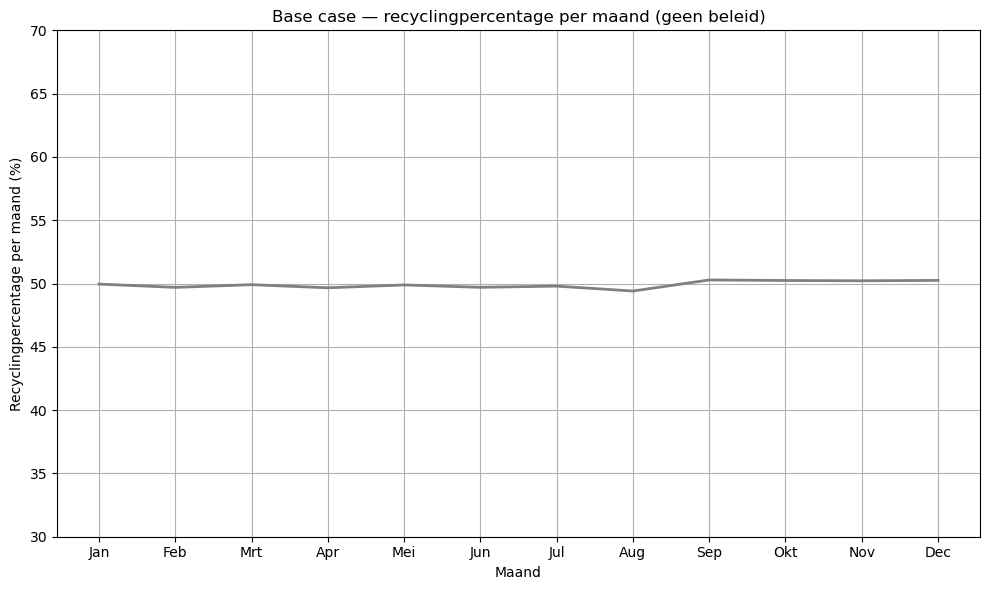

In [27]:
# Grafiek 1 — Recyclingpercentage per maand
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(base_enkel["Maand"], base_enkel["RecyclingPercentageDezeMaand"] * 100,
        color="gray", linewidth=2)
ax.set_xlabel("Maand")
ax.set_ylabel("Recyclingpercentage per maand (%)")
ax.set_title("Base case — recyclingpercentage per maand (geen beleid)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MAANDEN_LABELS)
ax.set_ylim(30, 70)
ax.grid(True)
plt.tight_layout()
plt.show()


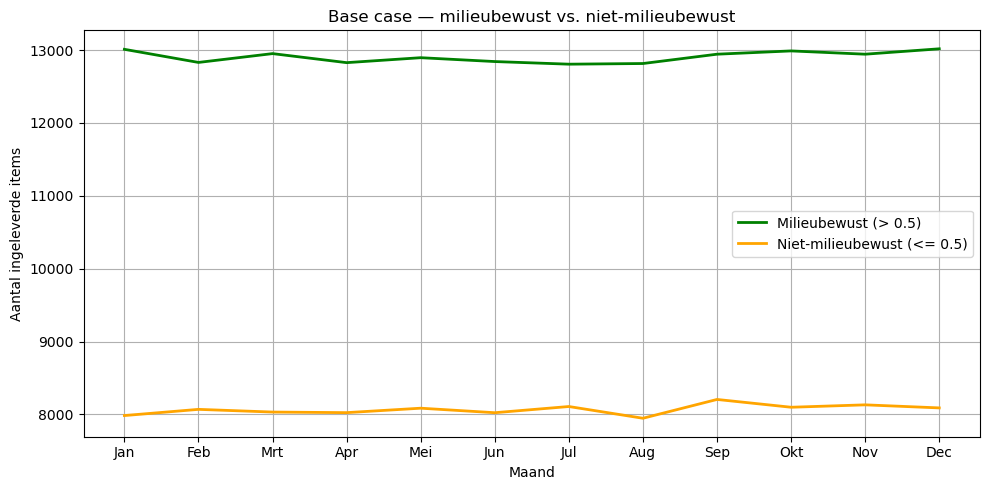

In [29]:
# Grafiek 2 — Milieubewust vs. niet-milieubewust
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(base_enkel["Maand"], base_enkel["TextielBewust"],
        label="Milieubewust (> 0.5)", color="green", linewidth=2)
ax.plot(base_enkel["Maand"], base_enkel["TextielOnbewust"],
        label="Niet-milieubewust (<= 0.5)", color="orange", linewidth=2)
ax.set_xlabel("Maand")
ax.set_ylabel("Aantal ingeleverde items")
ax.set_title("Base case — milieubewust vs. niet-milieubewust")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MAANDEN_LABELS)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


In [31]:
# Grafiek 3 — Kalibratie: 30 runs base case
AANTAL_RUNS_KALIBRATIE = 30
resultaten_kalibratie = []
for run in range(AANTAL_RUNS_KALIBRATIE):
    model = RotterdamModel(grid_size=GRID_SIZE, aantal_inzamelpunten=4,
                          maanden=N_MAANDEN, seed=run,
                          vaste_inzamelpunten=vaste_inzamelpunten)
    for _ in range(N_MAANDEN):
        model.step()
    data = model.datacollector.get_model_vars_dataframe()
    resultaten_kalibratie.append(data["RecyclingPercentage"].iloc[-1])

print(f"Kalibratie ({AANTAL_RUNS_KALIBRATIE} runs base case):")
print(f"  Gemiddelde        : {np.mean(resultaten_kalibratie):.3f}")
print(f"  Minimum           : {np.min(resultaten_kalibratie):.3f}")
print(f"  Maximum           : {np.max(resultaten_kalibratie):.3f}")
print(f"  Standaardafwijking: {np.std(resultaten_kalibratie):.3f}")


Kalibratie (30 runs base case):
  Gemiddelde        : 0.500
  Minimum           : 0.497
  Maximum           : 0.505
  Standaardafwijking: 0.002


In [33]:
#Verificatie A Printtest tussenvariabelen uitkomsten in tabel zetten in de bijlage
import math, numpy as np

# ── Verificatie A: Printtest ────────────────────────────────────────────
print('=' * 60)
print('VERIFICATIE A — Printtest tussenvariabelen')
print('=' * 60)

model_a = RotterdamModel(
    grid_size=GRID_SIZE, aantal_inzamelpunten=4,
    maanden=N_MAANDEN, seed=SEED_BASIS,
    vaste_inzamelpunten=vaste_inzamelpunten
)

# Draai 1 stap zodat maandwaarden gevuld zijn
model_a.step()

# Selecteer 3 steekproefagenten (vaste indices voor reproduceerbaarheid)
steekproef_ids = [0, 5000, 9999]
agents_dict = {a.unique_id: a for a in model_a.schedule.agents}

for aid in steekproef_ids:
    agent = agents_dict[aid]
    p = agent.bepaal_recycling_kans()
    print(f'\nAgent {aid}:')
    print(f'  milieubewustzijn          = {agent.milieubewustzijn:.3f}')
    print(f'  prijsgevoeligheid         = {agent.prijsgevoeligheid:.3f}')
    print(f'  gemaksgevoeligheid        = {agent.gemaksgevoeligheid:.3f}')
    print(f'  sociale_druk_gevoeligheid = {agent.sociale_druk_gevoeligheid:.3f}')
    print(f'  sociale_druk              = {agent.sociale_druk:.3f}')
    print(f'  afstand_inzamelpunt       = {agent.afstand_inzamelpunt:.2f}')
    print(f'  bekend_met_beloning       = {agent.bekend_met_beloning}')
    print(f'  p_recycle                 = {p:.4f}  [verwacht: 0 < p < 1]')
    print(f'  gerecycled_deze_maand     = {agent.gerecycled_deze_maand}')
    print(f'  weggegooid_deze_maand     = {agent.weggegooid_deze_maand}')
    verwacht_stukken = agent.gerecycled_deze_maand + agent.weggegooid_deze_maand
    print(f'  gerecycled + weggegooid   = {verwacht_stukken}  [≈ {agent.afgedankt_textiel:.2f} per maand]')

# Controlechecks
fouten = []
for a in model_a.schedule.agents:
    p = a.bepaal_recycling_kans()
    if not (0 <= p <= 1):
        fouten.append(f'Agent {a.unique_id}: p_recycle={p:.4f} buiten [0,1]')
    if not (0 <= a.sociale_druk <= 1):
        fouten.append(f'Agent {a.unique_id}: sociale_druk={a.sociale_druk:.3f} buiten [0,1]')

print(f'\nControle alle {len(list(model_a.schedule.agents))} agenten:')
if fouten:
    for f in fouten: print(f'  FOUT: {f}')
else:
    print('  OK — alle p_recycle en sociale_druk waarden binnen bereik')


VERIFICATIE A — Printtest tussenvariabelen

Agent 0:
  milieubewustzijn          = 0.639
  prijsgevoeligheid         = 0.025
  gemaksgevoeligheid        = 0.275
  sociale_druk_gevoeligheid = 0.223
  sociale_druk              = 0.500
  afstand_inzamelpunt       = 63.06
  bekend_met_beloning       = 0
  p_recycle                 = 0.5178  [verwacht: 0 < p < 1]
  gerecycled_deze_maand     = 2
  weggegooid_deze_maand     = 2
  gerecycled + weggegooid   = 4  [≈ 4.20 per maand]

Agent 5000:
  milieubewustzijn          = 0.882
  prijsgevoeligheid         = 0.500
  gemaksgevoeligheid        = 0.339
  sociale_druk_gevoeligheid = 0.255
  sociale_druk              = 0.500
  afstand_inzamelpunt       = 19.42
  bekend_met_beloning       = 0
  p_recycle                 = 0.6410  [verwacht: 0 < p < 1]
  gerecycled_deze_maand     = 3
  weggegooid_deze_maand     = 1
  gerecycled + weggegooid   = 4  [≈ 4.20 per maand]

Agent 9999:
  milieubewustzijn          = 0.193
  prijsgevoeligheid         = 0.139
 

In [35]:
#Verificatie B mass Balance uitkomsten in tabel zetten in de bijlage
print('=' * 60)
print('VERIFICATIE B — Mass balance')
print('=' * 60)

model_b = RotterdamModel(
    grid_size=GRID_SIZE, aantal_inzamelpunten=4,
    maanden=N_MAANDEN, seed=SEED_BASIS,
    vaste_inzamelpunten=vaste_inzamelpunten
)

totaal_verwacht = 0
fouten_mass = []

for maand in range(N_MAANDEN):
    model_b.step()
    for agent in model_b.schedule.agents:
        werkelijk = agent.gerecycled_deze_maand + agent.weggegooid_deze_maand
        # Verwacht is hele_stukken + eventueel 1 extra (rest_kans)
        # Dus werkelijk moet zijn: floor(afgedankt) of ceil(afgedankt)
        floor_val = int(agent.afgedankt_textiel)
        ceil_val  = floor_val + 1
        if werkelijk not in [floor_val, ceil_val]:
            fouten_mass.append(
                f'Maand {maand+1}, Agent {agent.unique_id}: '
                f'gerecycled+weggegooid={werkelijk}, verwacht {floor_val} of {ceil_val}'
            )
        totaal_verwacht += werkelijk

# Modelniveau check
data_b = model_b.datacollector.get_model_vars_dataframe()
totaal_gerecycled  = data_b['TotaalGerecycled'].iloc[-1]
totaal_weggegooid  = data_b['TotaalWeggegooid'].iloc[-1]
totaal_model       = totaal_gerecycled + totaal_weggegooid

print(f'TotaalGerecycled  = {totaal_gerecycled:,}')
print(f'TotaalWeggegooid  = {totaal_weggegooid:,}')
print(f'Som (model)       = {totaal_model:,}')
print(f'Som (agent-tel)   = {totaal_verwacht:,}')
print(f'Verschil          = {abs(totaal_model - totaal_verwacht)}')

if fouten_mass:
    print(f'\nAgentniveau: {len(fouten_mass)} fouten gevonden:')
    for f in fouten_mass[:5]: print(f'  {f}')
else:
    print('\nAgentniveau: OK — alle stukken correct geteld')

if totaal_model == totaal_verwacht:
    print('Modelniveau: OK — geen kledingstukken verdwenen of dubbel geteld')
else:
    print(f'Modelniveau: AFWIJKING van {abs(totaal_model - totaal_verwacht)} stukken')


VERIFICATIE B — Mass balance
TotaalGerecycled  = 251,674
TotaalWeggegooid  = 252,514
Som (model)       = 504,188
Som (agent-tel)   = 504,188
Verschil          = 0

Agentniveau: OK — alle stukken correct geteld
Modelniveau: OK — geen kledingstukken verdwenen of dubbel geteld


In [37]:
#Verificatie C Reproducibiliteit (seed test)
print('=' * 60)
print('VERIFICATIE C — Reproducibiliteit')
print('=' * 60)

def run_pct(seed):
    m = RotterdamModel(
        grid_size=GRID_SIZE, aantal_inzamelpunten=4,
        maanden=N_MAANDEN, seed=seed,
        vaste_inzamelpunten=vaste_inzamelpunten
    )
    for _ in range(N_MAANDEN): m.step()
    return m.datacollector.get_model_vars_dataframe()['RecyclingPercentage'].iloc[-1]

r1a = run_pct(42)
r1b = run_pct(42)
r2  = run_pct(99)

print(f'Run seed=42 (eerste keer) : {r1a:.6f}')
print(f'Run seed=42 (tweede keer) : {r1b:.6f}')
print(f'Verschil (moet 0 zijn)    : {abs(r1a - r1b):.6f}')
print(f'Run seed=99               : {r2:.6f}')
print(f'Verschil tov seed=42      : {abs(r1a - r2):.6f}  (moet > 0 zijn)')

print(f'\nReproducibiliteit: {"OK" if abs(r1a - r1b) == 0 else "FOUT"}')
print(f'Stochasticiteit:   {"OK" if abs(r1a - r2) > 0 else "FOUT"}')


VERIFICATIE C — Reproducibiliteit
Run seed=42 (eerste keer) : 0.499167
Run seed=42 (tweede keer) : 0.499167
Verschil (moet 0 zijn)    : 0.000000
Run seed=99               : 0.498937
Verschil tov seed=42      : 0.000230  (moet > 0 zijn)

Reproducibiliteit: OK
Stochasticiteit:   OK


VALIDATIE E — Macrovalidatie: base case vs. empirische data
Aantal runs           : 30
Gemiddelde recycling  : 0.500 (50.0%)
Standaardafwijking    : 0.002
Minimum               : 0.496
Maximum               : 0.503
Empirisch bereik      : [40%, 60%]
Binnen empirisch bereik: True


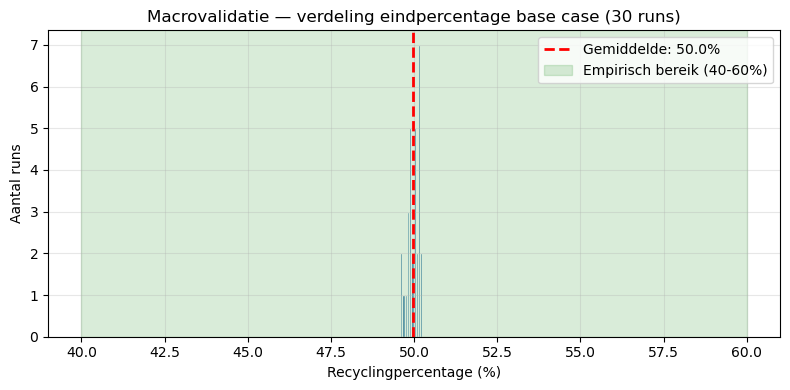

In [88]:
#Macrovalidatie Base case 50%
print('=' * 60)
print('VALIDATIE — Macrovalidatie: base case vs. empirische data')
print('=' * 60)

N_VALIDATIE_RUNS = 30
EMPIRISCH_MIN = 0.40
EMPIRISCH_MAX = 0.60

resultaten_e = []
for run in range(N_VALIDATIE_RUNS):
    m = RotterdamModel(
        grid_size=GRID_SIZE, aantal_inzamelpunten=4,
        maanden=N_MAANDEN, seed=run,
        vaste_inzamelpunten=vaste_inzamelpunten
    )
    for _ in range(N_MAANDEN): m.step()
    data_e = m.datacollector.get_model_vars_dataframe()
    resultaten_e.append(data_e['RecyclingPercentage'].iloc[-1])

gem_e  = np.mean(resultaten_e)
std_e  = np.std(resultaten_e)
min_e  = np.min(resultaten_e)
max_e  = np.max(resultaten_e)

print(f'Aantal runs           : {N_VALIDATIE_RUNS}')
print(f'Gemiddelde recycling  : {gem_e:.3f} ({gem_e*100:.1f}%)')
print(f'Standaardafwijking    : {std_e:.3f}')
print(f'Minimum               : {min_e:.3f}')
print(f'Maximum               : {max_e:.3f}')
print(f'Empirisch bereik      : [{EMPIRISCH_MIN*100:.0f}%, {EMPIRISCH_MAX*100:.0f}%]')
print(f'Binnen empirisch bereik: {EMPIRISCH_MIN <= gem_e <= EMPIRISCH_MAX}')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist([r * 100 for r in resultaten_e], bins=10, color='steelblue', edgecolor='white')
ax.axvline(gem_e * 100, color='red', linestyle='--', linewidth=2, label=f'Gemiddelde: {gem_e*100:.1f}%')
ax.axvspan(EMPIRISCH_MIN * 100, EMPIRISCH_MAX * 100, alpha=0.15, color='green', label='Empirisch bereik (40-60%)')
ax.set_xlabel('Recyclingpercentage (%)')
ax.set_ylabel('Aantal runs')
ax.set_title(f'Macrovalidatie — verdeling eindpercentage base case ({N_VALIDATIE_RUNS} runs)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Deel 4 — Beleidsvorm 1: financiële beloning

Effect van een beloning per ingeleverd kledingstuk (€0 t/m €5).
Bekendheid met de beloning verspreidt via burendiffusie; 5% start al bekend.
Het effect volgt een S-curve met buigpunt bij €3.

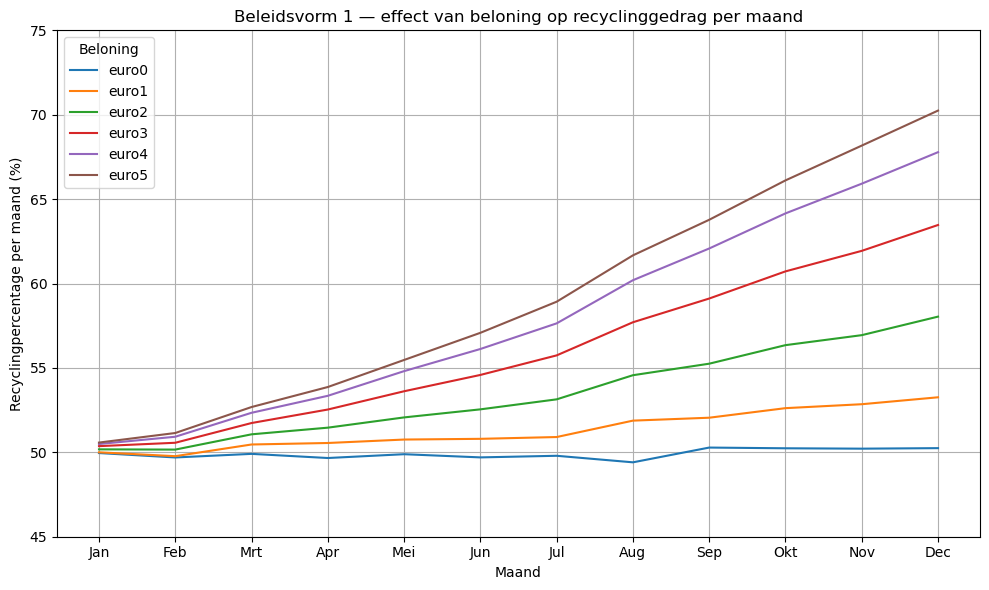

In [41]:
# Grafiek 4 — Recyclingpercentage per maand per beloningsniveau
fig, ax = plt.subplots(figsize=(10, 6))
for b in BELONINGEN:
    data = b1_enkel[b]
    ax.plot(data["Maand"], data["RecyclingPercentageDezeMaand"] * 100, label=f"euro{b}")
ax.set_xlabel("Maand")
ax.set_ylabel("Recyclingpercentage per maand (%)")
ax.set_title("Beleidsvorm 1 — effect van beloning op recyclinggedrag per maand")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MAANDEN_LABELS)
ax.legend(title="Beloning")
ax.set_ylim(45, 75)
ax.grid(True)
plt.tight_layout()
plt.show()


 Beloning  EindRecyclingPercentage
        0                 0.499167
        1                 0.513253
        2                 0.534800
        3                 0.560064
        4                 0.579823
        5                 0.591421


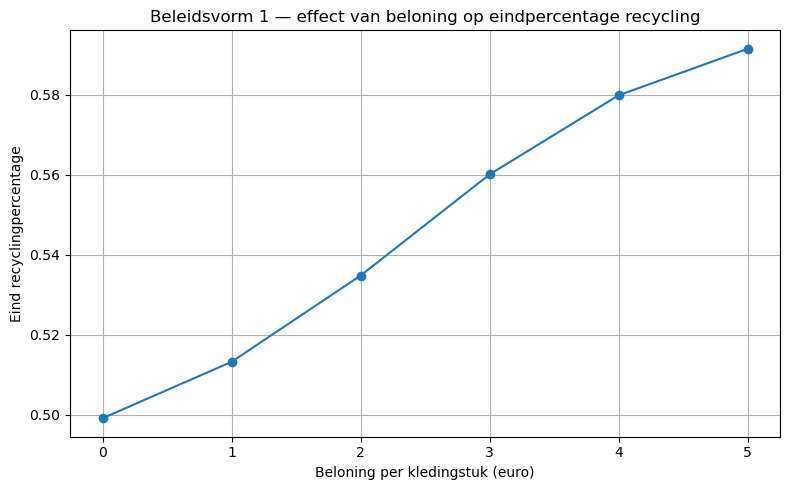

In [43]:
# Grafiek 6 — Effect op eindpercentage per beloningsniveau
eindresultaten = [
    {"Beloning": b, "EindRecyclingPercentage": b1_enkel[b]["RecyclingPercentage"].iloc[-1]}
    for b in BELONINGEN
]
df_eind_b1 = pd.DataFrame(eindresultaten)
print(df_eind_b1.to_string(index=False))
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_eind_b1["Beloning"], df_eind_b1["EindRecyclingPercentage"], marker="o")
ax.set_xlabel("Beloning per kledingstuk (euro)")
ax.set_ylabel("Eind recyclingpercentage")
ax.set_title("Beleidsvorm 1 — effect van beloning op eindpercentage recycling")
ax.grid(True)
plt.tight_layout()
plt.show()


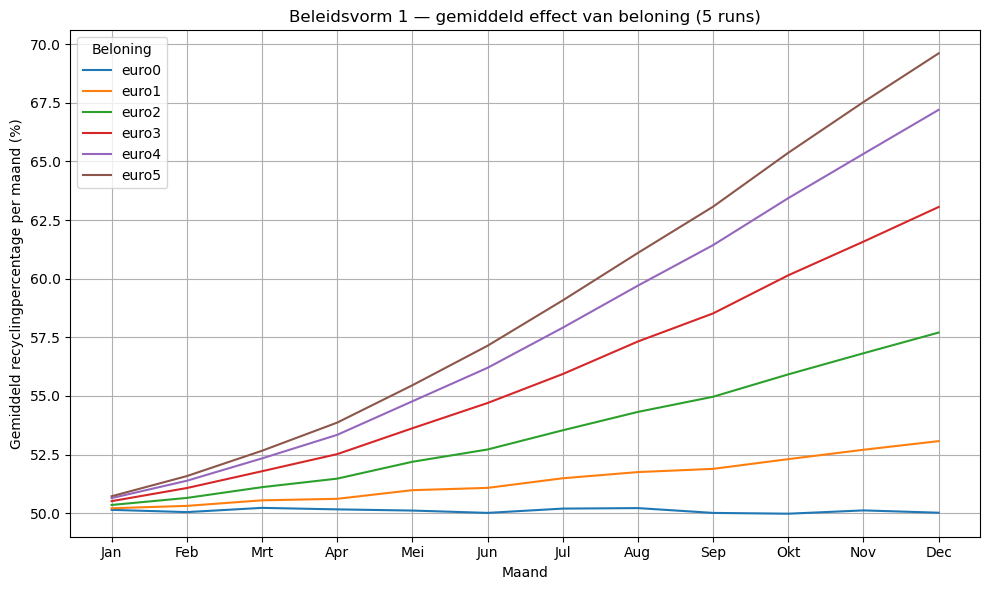

In [45]:
# Grafiek 7 — Gemiddeld effect over meerdere runs
fig, ax = plt.subplots(figsize=(10, 6))
for b in BELONINGEN:
    resultaten = b1_meer[b]
    gem = resultaten.groupby("Maand")["RecyclingPercentageDezeMaand"].mean()
    ax.plot(gem.index, gem.values * 100, label=f"euro{b}")
ax.set_xlabel("Maand")
ax.set_ylabel("Gemiddeld recyclingpercentage per maand (%)")
ax.set_title(f"Beleidsvorm 1 — gemiddeld effect van beloning ({N_RUNS} runs)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MAANDEN_LABELS)
ax.legend(title="Beloning")
ax.grid(True)
plt.tight_layout()
plt.show()


 Beloning  GemiddeldeEindscore      Std
        0             0.501034 0.000914
        1             0.514135 0.000890
        2             0.534804 0.000697
        3             0.558991 0.000729
        4             0.578088 0.000957
        5             0.589341 0.001110


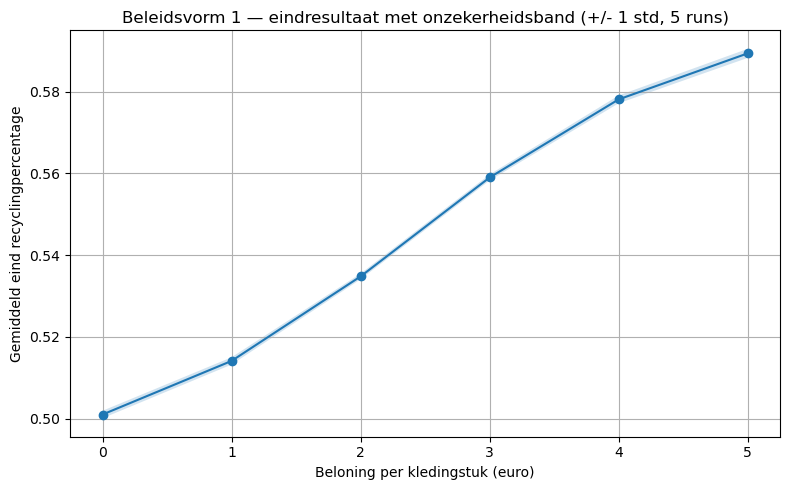

In [47]:
# Grafiek 8 — Gemiddeld eindresultaat met onzekerheidsband
samenvatting_b1 = []
for b in BELONINGEN:
    resultaten  = b1_meer[b]
    eind_maand  = resultaten["Maand"].max()
    eindwaarden = resultaten[resultaten["Maand"] == eind_maand]["RecyclingPercentage"]
    samenvatting_b1.append({"Beloning": b,
                            "GemiddeldeEindscore": eindwaarden.mean(),
                            "Std": eindwaarden.std()})
df_b1 = pd.DataFrame(samenvatting_b1)
print(df_b1.to_string(index=False))
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_b1["Beloning"], df_b1["GemiddeldeEindscore"], marker="o")
ax.fill_between(
    df_b1["Beloning"],
    df_b1["GemiddeldeEindscore"] - df_b1["Std"],
    df_b1["GemiddeldeEindscore"] + df_b1["Std"],
    alpha=0.2
)
ax.set_xlabel("Beloning per kledingstuk (euro)")
ax.set_ylabel("Gemiddeld eind recyclingpercentage")
ax.set_title(f"Beleidsvorm 1 — eindresultaat met onzekerheidsband (+/- 1 std, {N_RUNS} runs)")
ax.grid(True)
plt.tight_layout()
plt.show()


---
## Deel 5 — Beleidsvorm 2: meer inzamelpunten

Effect van het uitbreiden van het aantal inzamelpunten (4 / 6 / 8).
Agenten ontdekken nieuwe inzamelpunten geleidelijk: de waargenomen afstand
convergeert via leersnelheid 0.25 naar de echte afstand (~96% na 8 maanden).
Geen financiële beloning actief in dit deel.

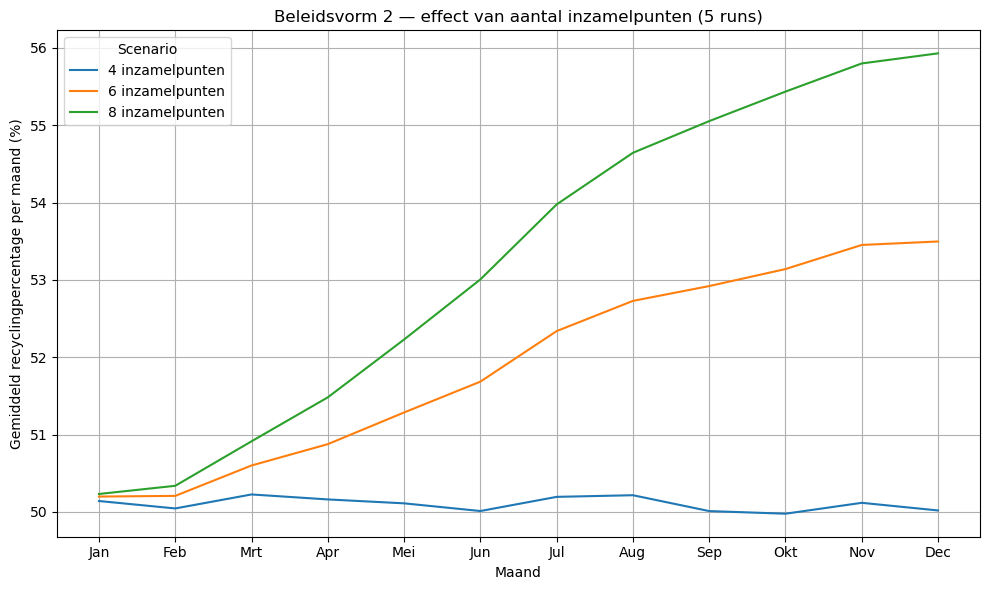

In [50]:
# Grafiek 9 — Recyclingpercentage per maand per scenario
fig, ax = plt.subplots(figsize=(10, 6))
for n in INZAMELPUNTEN_SCENARIOS:
    resultaten = b2_meer[n]
    gem = resultaten.groupby("Maand")["RecyclingPercentageDezeMaand"].mean()
    ax.plot(gem.index, gem.values * 100, label=f"{n} inzamelpunten")
ax.set_xlabel("Maand")
ax.set_ylabel("Gemiddeld recyclingpercentage per maand (%)")
ax.set_title(f"Beleidsvorm 2 — effect van aantal inzamelpunten ({N_RUNS} runs)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MAANDEN_LABELS)
ax.legend(title="Scenario")
ax.grid(True)
plt.tight_layout()
plt.show()


 AantalPunten  GemiddeldeEindscore      Std
            4             0.500835 0.000822
            6             0.511322 0.000682
            8             0.519302 0.000674


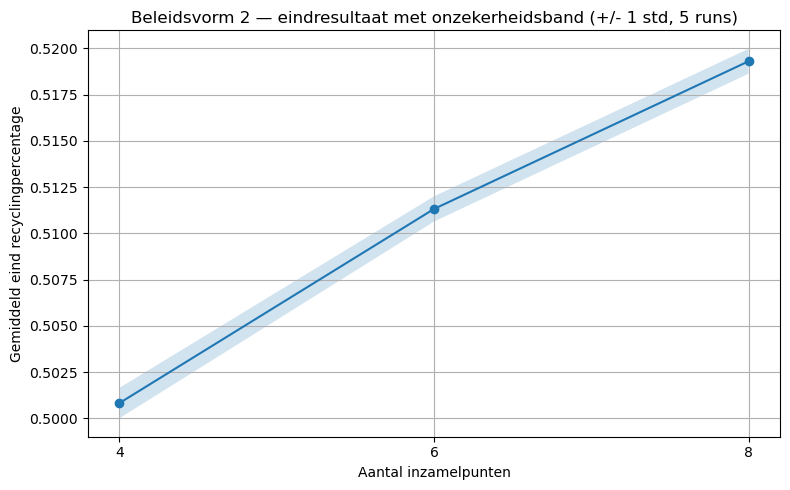

In [35]:
# Grafiek 11 — Eindresultaat met onzekerheidsband
samenvatting_b2 = []
for n in INZAMELPUNTEN_SCENARIOS:
    resultaten  = b2_meer[n]
    eind_maand  = resultaten["Maand"].max()
    eindwaarden = resultaten[resultaten["Maand"] == eind_maand]["RecyclingPercentage"]
    samenvatting_b2.append({"AantalPunten": n,
                            "GemiddeldeEindscore": eindwaarden.mean(),
                            "Std": eindwaarden.std()})
df_b2 = pd.DataFrame(samenvatting_b2)
print(df_b2.to_string(index=False))
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_b2["AantalPunten"], df_b2["GemiddeldeEindscore"], marker="o")
ax.fill_between(
    df_b2["AantalPunten"],
    df_b2["GemiddeldeEindscore"] - df_b2["Std"],
    df_b2["GemiddeldeEindscore"] + df_b2["Std"],
    alpha=0.2
)
ax.set_xlabel("Aantal inzamelpunten")
ax.set_ylabel("Gemiddeld eind recyclingpercentage")
ax.set_title(f"Beleidsvorm 2 — eindresultaat met onzekerheidsband (+/- 1 std, {N_RUNS} runs)")
ax.set_xticks(INZAMELPUNTEN_SCENARIOS)
ax.grid(True)
plt.tight_layout()
plt.show()


---
## Deel 6 — Gecombineerd: beleidsvorm 1 + 2

Directe vergelijking van alle vier scenario's:

| Scenario | Beloning | Inzamelpunten |
|---|---|---|
| Base case | €0 | 4 |
| Alleen beloning | €3 | 4 |
| Alleen meer punten | €0 | 8 |
| **Gecombineerd** | **€3** | **8** |

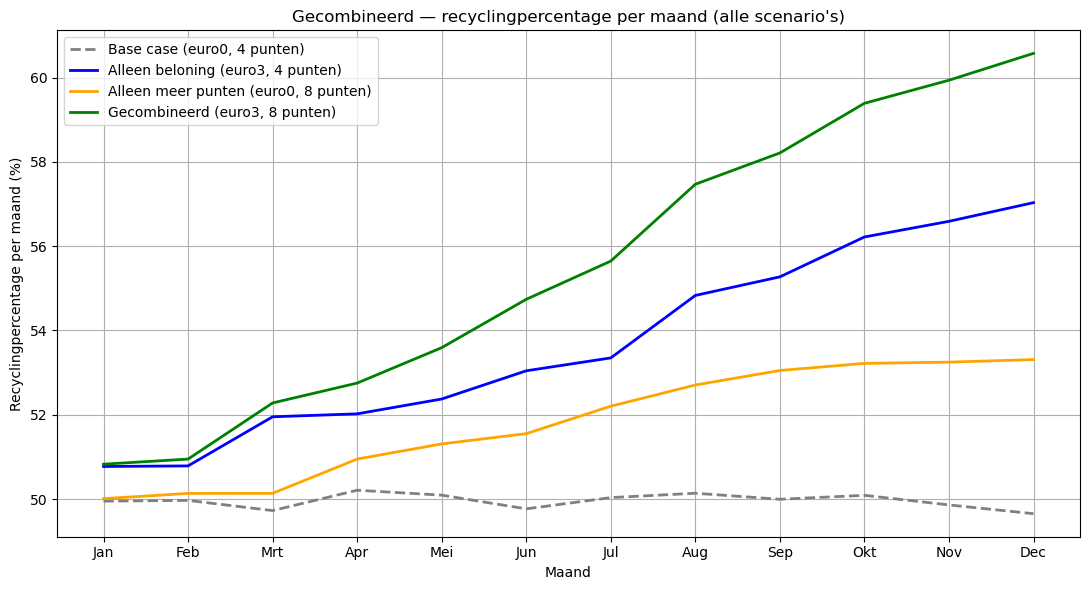

In [38]:
# Grafiek 12 — Recyclingpercentage per maand (enkelvoudig)
fig, ax = plt.subplots(figsize=(11, 6))
for label, b, n, kleur, ls in COMBO_SCENARIOS:
    data = combo_enkel[(b, n)]
    ax.plot(data["Maand"], data["RecyclingPercentageDezeMaand"] * 100,
            label=label, color=kleur, linestyle=ls, linewidth=2)
ax.set_xlabel("Maand")
ax.set_ylabel("Recyclingpercentage per maand (%)")
ax.set_title("Gecombineerd — recyclingpercentage per maand (alle scenario's)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MAANDEN_LABELS)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


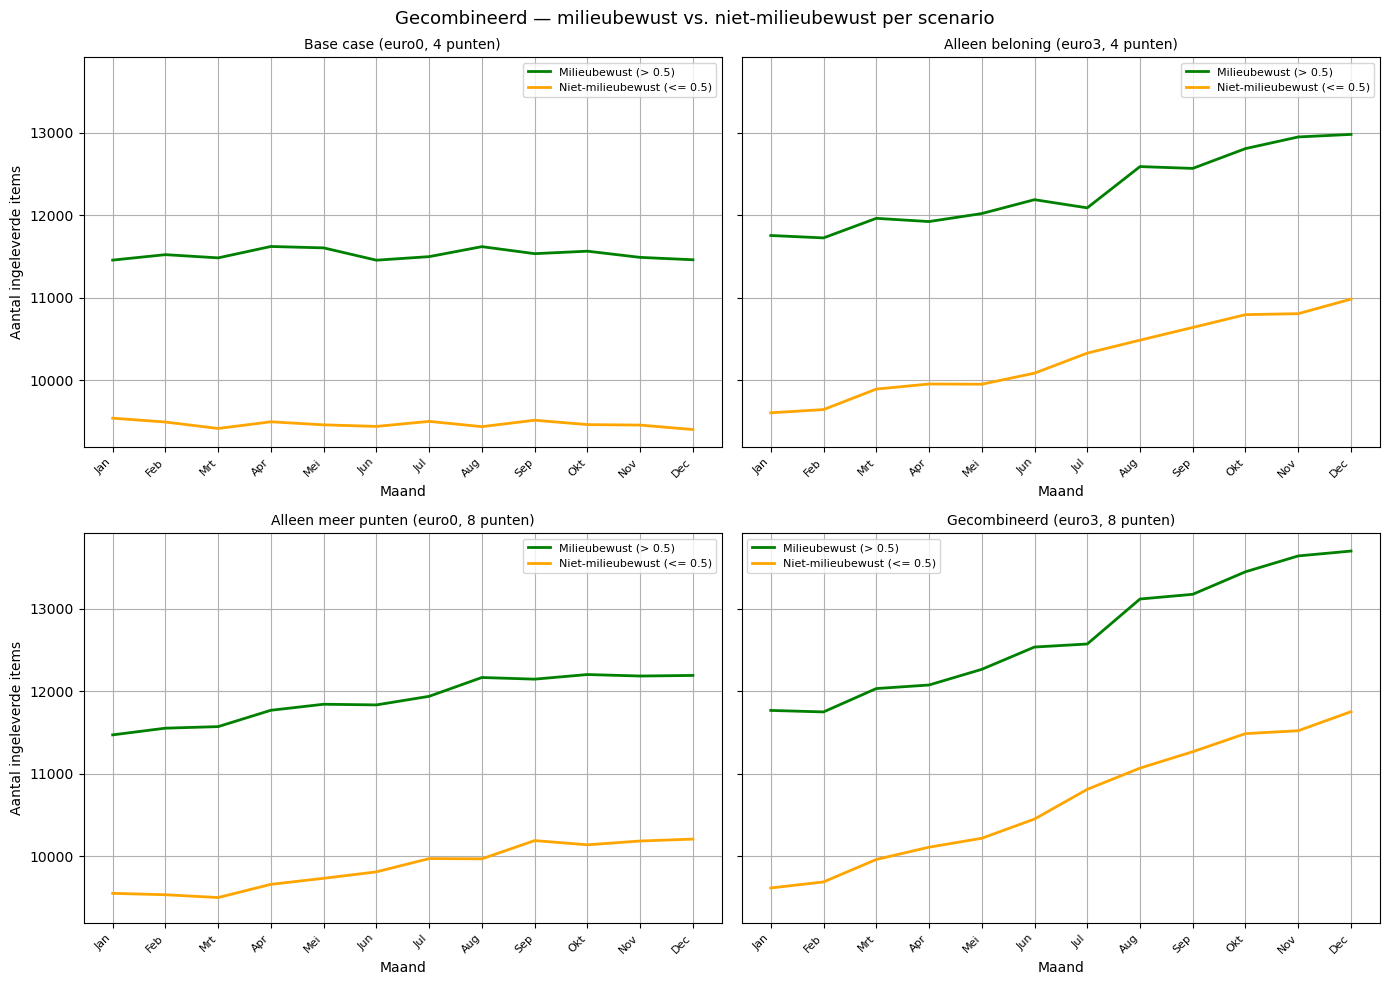

In [42]:
# Grafiek 14 — Milieubewust vs. niet per scenario (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()
for ax, (label, b, n, kleur, ls) in zip(axes, COMBO_SCENARIOS):
    data = combo_enkel[(b, n)]
    ax.plot(data["Maand"], data["TextielBewust"],
            label="Milieubewust (> 0.5)", color="green", linewidth=2)
    ax.plot(data["Maand"], data["TextielOnbewust"],
            label="Niet-milieubewust (<= 0.5)", color="orange", linewidth=2)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Maand")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MAANDEN_LABELS, rotation=45, ha="right", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True)
axes[0].set_ylabel('Aantal ingeleverde items')
axes[2].set_ylabel('Aantal ingeleverde items')
fig.suptitle("Gecombineerd — milieubewust vs. niet-milieubewust per scenario", fontsize=13)
plt.tight_layout()
plt.show()


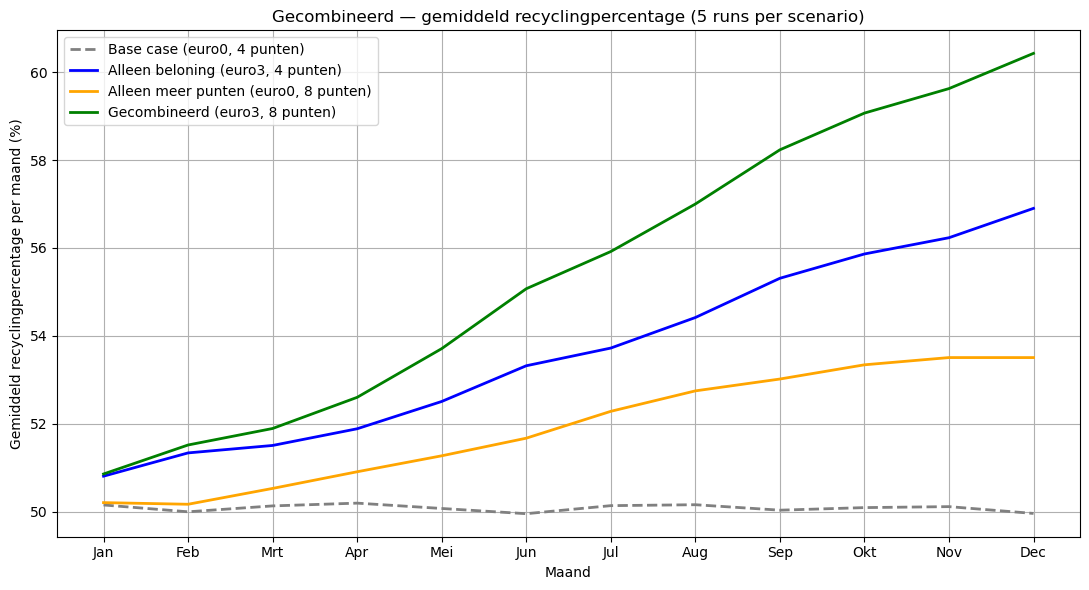

In [44]:
# Grafiek 15 — Gemiddeld recyclingpercentage (meerdere runs)
fig, ax = plt.subplots(figsize=(11, 6))
for label, b, n, kleur, ls in COMBO_SCENARIOS:
    resultaten = combo_meer[(b, n)]
    gem = resultaten.groupby("Maand")["RecyclingPercentageDezeMaand"].mean()
    ax.plot(gem.index, gem.values * 100,
            label=label, color=kleur, linestyle=ls, linewidth=2)
ax.set_xlabel("Maand")
ax.set_ylabel("Gemiddeld recyclingpercentage per maand (%)")
ax.set_title(f"Gecombineerd — gemiddeld recyclingpercentage ({N_RUNS} runs per scenario)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MAANDEN_LABELS)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


                            Scenario  GemiddeldeEindscore      Std
         Base case (euro0, 4 punten)             0.500835 0.000822
   Alleen beloning (euro3, 4 punten)             0.536514 0.001376
Alleen meer punten (euro0, 8 punten)             0.519302 0.000674
      Gecombineerd (euro3, 8 punten)             0.554943 0.001375


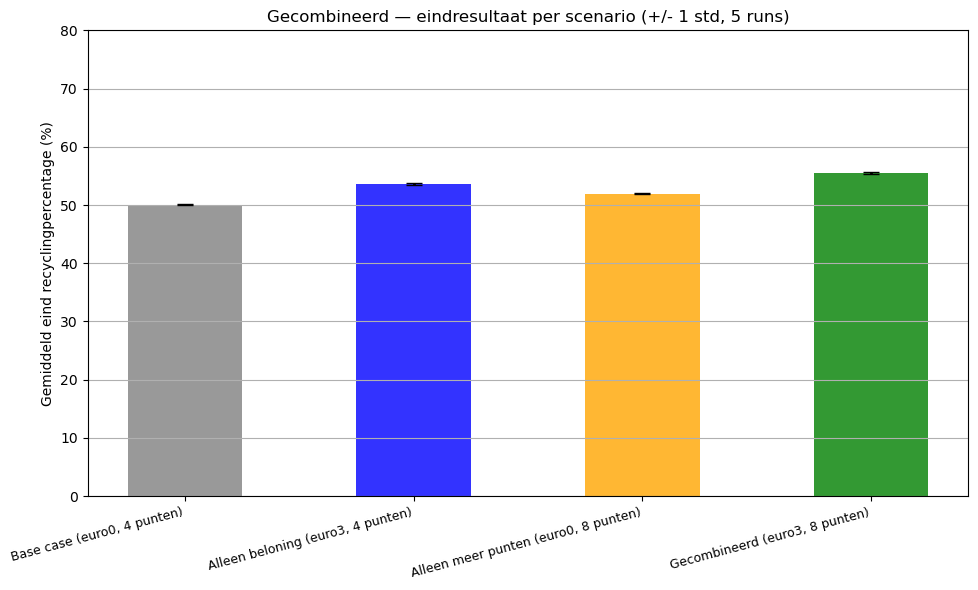

In [46]:
# Grafiek 16 — Eindresultaat als staafdiagram met std
samenvatting_combo = []
for label, b, n, kleur, ls in COMBO_SCENARIOS:
    resultaten  = combo_meer[(b, n)]
    eind_maand  = resultaten["Maand"].max()
    eindwaarden = resultaten[resultaten["Maand"] == eind_maand]["RecyclingPercentage"]
    samenvatting_combo.append({"Scenario": label,
                               "GemiddeldeEindscore": eindwaarden.mean(),
                               "Std": eindwaarden.std(),
                               "Kleur": kleur})
df_combo = pd.DataFrame(samenvatting_combo)
print(df_combo[["Scenario", "GemiddeldeEindscore", "Std"]].to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(df_combo))
ax.bar(x, df_combo["GemiddeldeEindscore"] * 100,
       color=df_combo["Kleur"], alpha=0.8, width=0.5)
ax.errorbar(x, df_combo["GemiddeldeEindscore"] * 100,
            yerr=df_combo["Std"] * 100,
            fmt="none", color="black", capsize=6, linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(df_combo["Scenario"], rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Gemiddeld eind recyclingpercentage (%)")
ax.set_title(f"Gecombineerd — eindresultaat per scenario (+/- 1 std, {N_RUNS} runs)")
ax.set_ylim(0, 80)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()


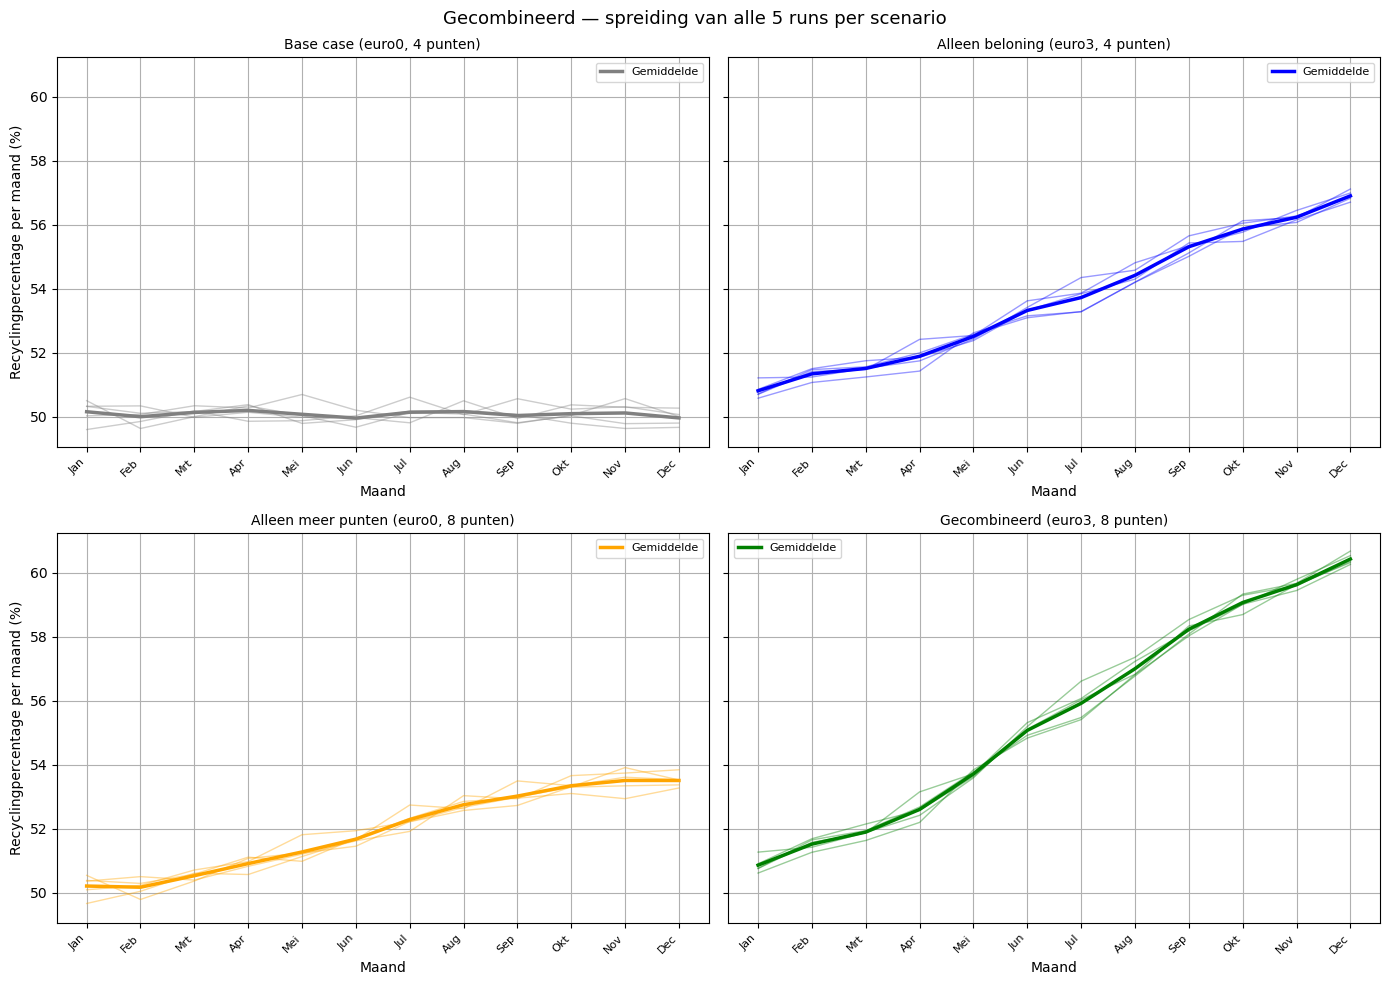

In [48]:
# Grafiek 17 — Spreiding individuele runs per scenario (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()
for ax, (label, b, n, kleur, ls) in zip(axes, COMBO_SCENARIOS):
    resultaten = combo_meer[(b, n)]
    for run_id in resultaten["Run"].unique():
        run_data = resultaten[resultaten["Run"] == run_id]
        ax.plot(run_data["Maand"], run_data["RecyclingPercentageDezeMaand"] * 100,
                color=kleur, alpha=0.4, linewidth=1)
    gem = resultaten.groupby("Maand")["RecyclingPercentageDezeMaand"].mean()
    ax.plot(gem.index, gem.values * 100, color=kleur, linewidth=2.5, label="Gemiddelde")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Maand")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MAANDEN_LABELS, rotation=45, ha="right", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True)
axes[0].set_ylabel('Recyclingpercentage per maand (%)')
axes[2].set_ylabel('Recyclingpercentage per maand (%)')
fig.suptitle(f"Gecombineerd — spreiding van alle {N_RUNS} runs per scenario", fontsize=13)
plt.tight_layout()
plt.show()
